In [3]:
%pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv(r'C:\Sales Analysis\data\processed\cleaned_sales_no_outliers.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,IsCancelled,Revenue,Month
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490,United Kingdom,False,257.64,2019-12
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069,United Kingdom,False,383.40,2019-12
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069,United Kingdom,False,138.36,2019-12
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069,United Kingdom,False,127.80,2019-12
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069,United Kingdom,False,71.64,2019-12


In [5]:
df['OrderMonth'] = df['Date'].dt.to_period('M')
df['CohortMonth'] = df.groupby('CustomerNo')['Date'].transform('min').dt.to_period('M')

df[['CustomerNo', 'Date', 'OrderMonth', 'CohortMonth']].head(10)

,CustomerNo,Date,OrderMonth,CohortMonth
0,17490,2019-12-09,2019-12,2019-06
1,13069,2019-12-09,2019-12,2018-12
2,13069,2019-12-09,2019-12,2018-12
3,13069,2019-12-09,2019-12,2018-12
4,13069,2019-12-09,2019-12,2018-12
5,13069,2019-12-09,2019-12,2018-12
6,13069,2019-12-09,2019-12,2018-12
7,13069,2019-12-09,2019-12,2018-12
8,13069,2019-12-09,2019-12,2018-12
9,13069,2019-12-09,2019-12,2018-12


In [6]:
def get_cohort_index(row):
    return (row['OrderMonth'].year - row['CohortMonth'].year) * 12 + (row['OrderMonth'].month - row['CohortMonth'].month) + 1

df['CohortIndex'] = df.apply(get_cohort_index, axis=1)
df[['CustomerNo', 'OrderMonth', 'CohortMonth', 'CohortIndex']].head(10)

,CustomerNo,OrderMonth,CohortMonth,CohortIndex
0,17490,2019-12,2019-06,7
1,13069,2019-12,2018-12,13
2,13069,2019-12,2018-12,13
3,13069,2019-12,2018-12,13
4,13069,2019-12,2018-12,13
5,13069,2019-12,2018-12,13
6,13069,2019-12,2018-12,13
7,13069,2019-12,2018-12,13
8,13069,2019-12,2018-12,13
9,13069,2019-12,2018-12,13


In [7]:
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerNo'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerNo')

cohort_pivot

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2018-12,1026.0,341.0,310.0,368.0,355.0,385.0,359.0,346.0,333.0,388.0,369.0,492.0,248.0
2019-01,485.0,98.0,127.0,111.0,147.0,136.0,113.0,114.0,138.0,154.0,166.0,56.0,NaN
2019-02,438.0,83.0,80.0,114.0,115.0,98.0,105.0,117.0,103.0,132.0,30.0,NaN,NaN
2019-03,503.0,71.0,115.0,95.0,116.0,83.0,131.0,117.0,143.0,47.0,NaN,NaN,NaN
2019-04,321.0,66.0,60.0,63.0,62.0,74.0,69.0,83.0,25.0,NaN,NaN,NaN,NaN
2019-05,332.0,62.0,62.0,55.0,68.0,73.0,84.0,27.0,NaN,NaN,NaN,NaN,NaN
2019-06,274.0,48.0,41.0,60.0,62.0,79.0,29.0,NaN,NaN,NaN,NaN,NaN,NaN
2019-07,211.0,31.0,37.0,43.0,63.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,173.0,32.0,41.0,39.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
cohort_size = cohort_pivot.iloc[:, 0]  # first column = original cohort size
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

retention.round(1)

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2018-12,100.0,33.2,30.2,35.9,34.6,37.5,35.0,33.7,32.5,37.8,36.0,48.0,24.2
2019-01,100.0,20.2,26.2,22.9,30.3,28.0,23.3,23.5,28.5,31.8,34.2,11.5,NaN
2019-02,100.0,18.9,18.3,26.0,26.3,22.4,24.0,26.7,23.5,30.1,6.8,NaN,NaN
2019-03,100.0,14.1,22.9,18.9,23.1,16.5,26.0,23.3,28.4,9.3,NaN,NaN,NaN
2019-04,100.0,20.6,18.7,19.6,19.3,23.1,21.5,25.9,7.8,NaN,NaN,NaN,NaN
2019-05,100.0,18.7,18.7,16.6,20.5,22.0,25.3,8.1,NaN,NaN,NaN,NaN,NaN
2019-06,100.0,17.5,15.0,21.9,22.6,28.8,10.6,NaN,NaN,NaN,NaN,NaN,NaN
2019-07,100.0,14.7,17.5,20.4,29.9,10.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,100.0,18.5,23.7,22.5,11.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


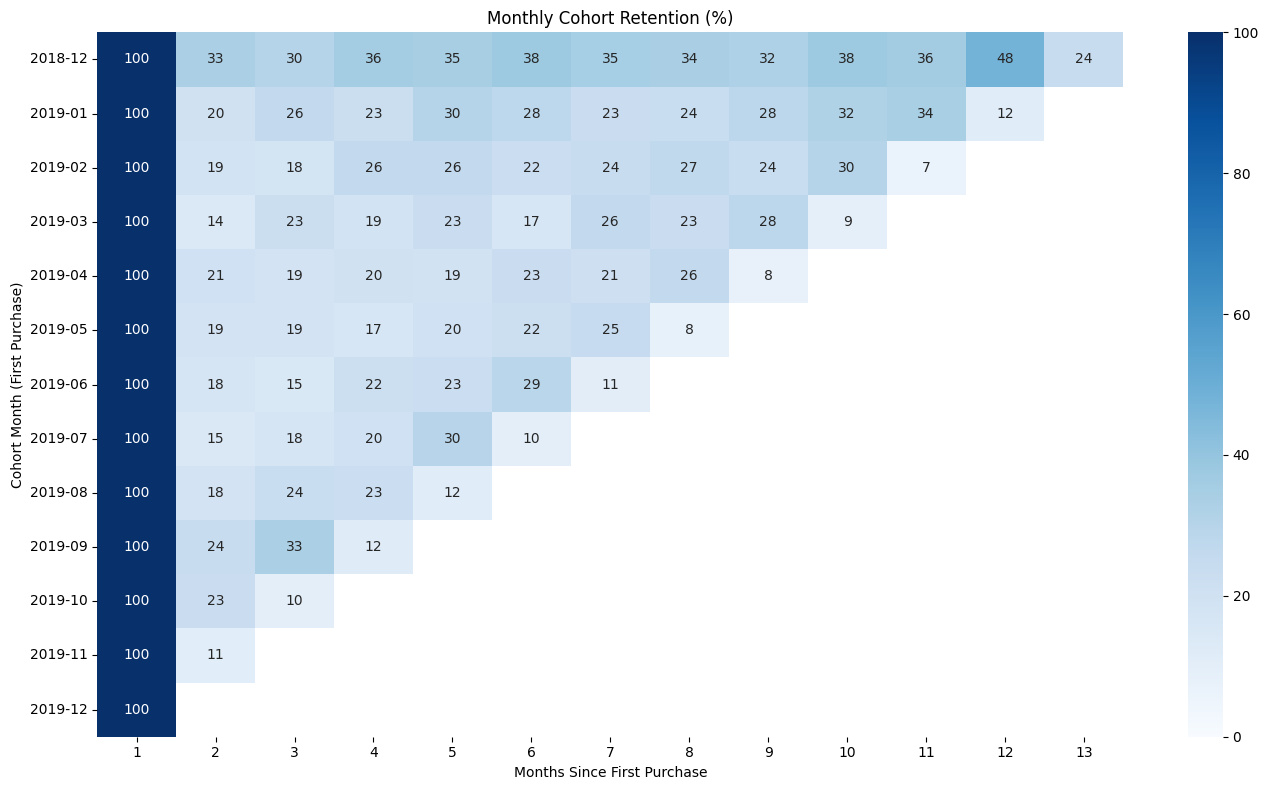

In [10]:
plt.figure(figsize=(14, 8))
sns.heatmap(retention, annot=True, fmt='.0f', cmap='Blues', vmin=0, vmax=100)
plt.title('Monthly Cohort Retention (%)')
plt.ylabel('Cohort Month (First Purchase)')
plt.xlabel('Months Since First Purchase')
plt.tight_layout()
plt.savefig(r'C:\Sales Analysis\output\figures\cohort_retention_heatmap.png')
plt.show()

CohortIndex
1     100.0
2      19.6
3      21.3
4      21.7
5      24.2
6      23.6
7      23.7
8      23.5
9      24.1
10     27.3
11     25.7
12     29.7
13     24.2
dtype: float64


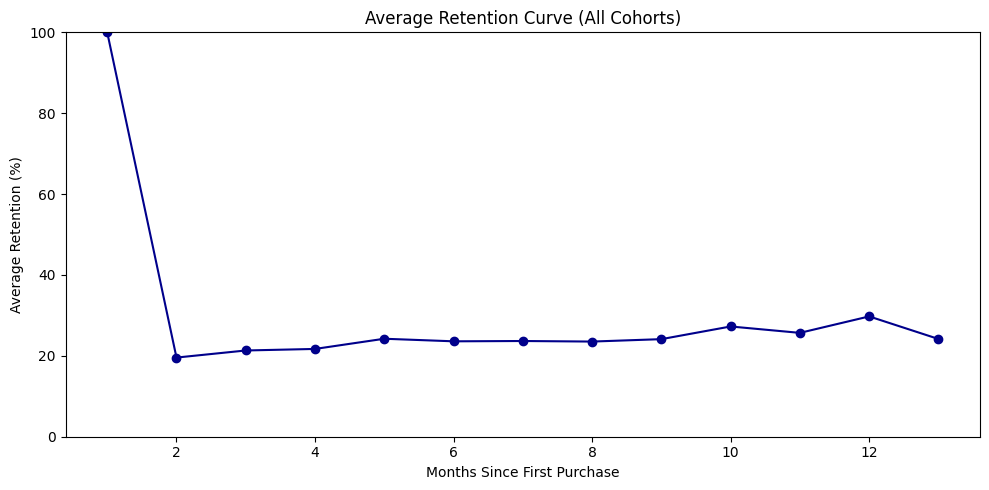

In [11]:
avg_retention = retention.mean(axis=0)
print(avg_retention.round(1))

plt.figure(figsize=(10,5))
avg_retention.plot(kind='line', marker='o', color='darkblue')
plt.title('Average Retention Curve (All Cohorts)')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Average Retention (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(r'C:\Sales Analysis\output\figures\avg_retention_curve.png')
plt.show()

In [14]:
retention.to_csv(r'C:\Sales Analysis\output\tables\cohort_retention_table.csv')
cohort_pivot.to_csv(r'C:\Sales Analysis\output\tables\cohort_customer_counts.csv')
print("Saved cohort outputs")

Saved cohort outputs
